# Minecraft Mob Detection

Ноутбук для EDA, подготовки данных, обучения FCOS и YOLOv8s, инференса и сравнения метрик.


## 1. Инициализация

In [1]:
import os
from pathlib import Path

LOCAL_CACHE = Path('.cache_runtime')
LOCAL_CACHE.mkdir(exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(LOCAL_CACHE / 'matplotlib'))
os.environ.setdefault('XDG_CACHE_HOME', str(LOCAL_CACHE))

import matplotlib.pyplot as plt
import pandas as pd

from project_tools import (
    MINECRAFT_CLASSES,
    build_fcos_config_path,
    build_yolo_data_yaml,
    coco_annotation_summary,
    compare_model_metrics,
    draw_coco_sample,
    plot_class_distribution,
    prepare_yolo_labels,
    run_fcos_image_inference,
    run_fcos_test_evaluation,
    run_fcos_training,
    run_yolo_image_inference,
    run_yolo_training,
    run_yolo_validation,
    save_metrics_comparison,
    validate_coco_annotations,
)

PROJECT_ROOT = Path.cwd()
DATASET_ROOT = PROJECT_ROOT / 'datasets' / 'minecraft'
ANNOTATIONS_ROOT = DATASET_ROOT / 'annotations'
ARTIFACTS_ROOT = PROJECT_ROOT / 'artifacts'
FCOS_ARTIFACTS = ARTIFACTS_ROOT / 'fcos'
YOLO_ARTIFACTS = ARTIFACTS_ROOT / 'yolo'
INFERENCE_ROOT = ARTIFACTS_ROOT / 'inference'
VIDEOS_ROOT = ARTIFACTS_ROOT / 'videos'
METRICS_ROOT = ARTIFACTS_ROOT / 'metrics'

SMOKE_RUN = False

RUN_FCOS_TRAINING = True
RUN_YOLO_TRAINING = True

PROJECT_ROOT, DATASET_ROOT

(PosixPath('/Users/borisfox/Documents/ML/nn/sprint 5/project/mmdetection'),
 PosixPath('/Users/borisfox/Documents/ML/nn/sprint 5/project/mmdetection/datasets/minecraft'))

## 2. Проверка структуры датасета

In [2]:
validation_reports = {}
for split in ['train', 'val', 'test']:
    report = validate_coco_annotations(
        ANNOTATIONS_ROOT / f'{split}_annotations.json',
        DATASET_ROOT / split,
    )
    validation_reports[split] = report
    print(split, report)

validation_reports

train {'images_in_json': 2307, 'annotations_in_json': 4029, 'categories_in_json': 18, 'annotations_without_images': [], 'missing_on_disk': [], 'extra_on_disk': [], 'is_valid': True}
val {'images_in_json': 422, 'annotations_in_json': 697, 'categories_in_json': 18, 'annotations_without_images': [], 'missing_on_disk': [], 'extra_on_disk': [], 'is_valid': True}
test {'images_in_json': 155, 'annotations_in_json': 351, 'categories_in_json': 18, 'annotations_without_images': [], 'missing_on_disk': [], 'extra_on_disk': [], 'is_valid': True}


{'train': {'images_in_json': 2307,
  'annotations_in_json': 4029,
  'categories_in_json': 18,
  'annotations_without_images': [],
  'missing_on_disk': [],
  'extra_on_disk': [],
  'is_valid': True},
 'val': {'images_in_json': 422,
  'annotations_in_json': 697,
  'categories_in_json': 18,
  'annotations_without_images': [],
  'missing_on_disk': [],
  'extra_on_disk': [],
  'is_valid': True},
 'test': {'images_in_json': 155,
  'annotations_in_json': 351,
  'categories_in_json': 18,
  'annotations_without_images': [],
  'missing_on_disk': [],
  'extra_on_disk': [],
  'is_valid': True}}

In [3]:
train_summary = coco_annotation_summary(ANNOTATIONS_ROOT / 'train_annotations.json')
pd.Series({
    'images': train_summary['images'],
    'annotations': train_summary['annotations'],
    'categories_in_json': len(train_summary['categories']),
    'target_classes': len(MINECRAFT_CLASSES),
})

images                2307
annotations           4029
categories_in_json      18
target_classes          17
dtype: int64

## 3. EDA

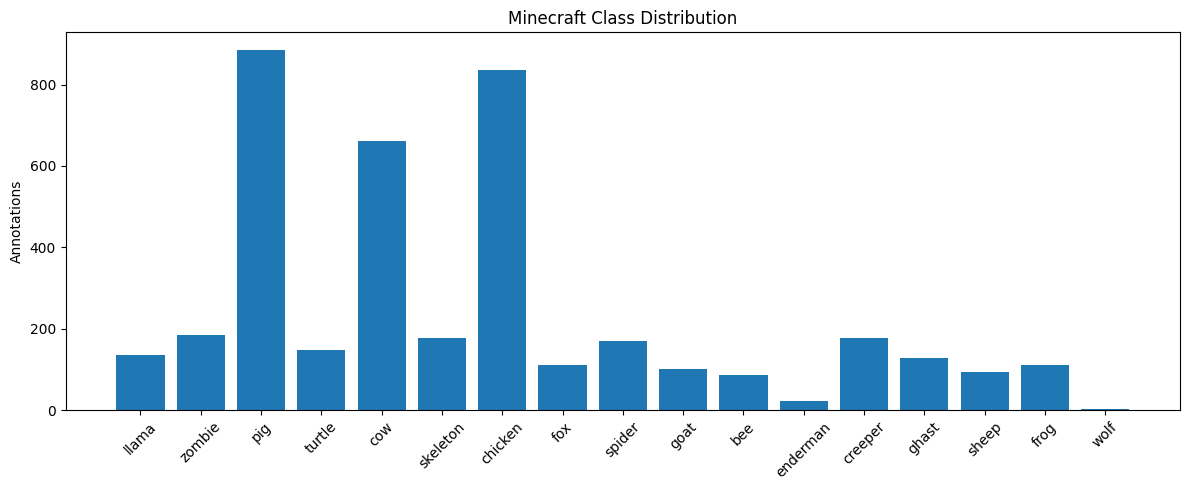

pig         884
chicken     835
cow         661
zombie      184
skeleton    177
creeper     177
spider      170
turtle      149
llama       135
ghast       127
fox         111
frog        111
goat        102
sheep        94
bee          86
enderman     22
wolf          4
dtype: int64

In [4]:
fig, ax, counts = plot_class_distribution(ANNOTATIONS_ROOT / 'train_annotations.json')
plt.show()
pd.Series(counts).sort_values(ascending=False)

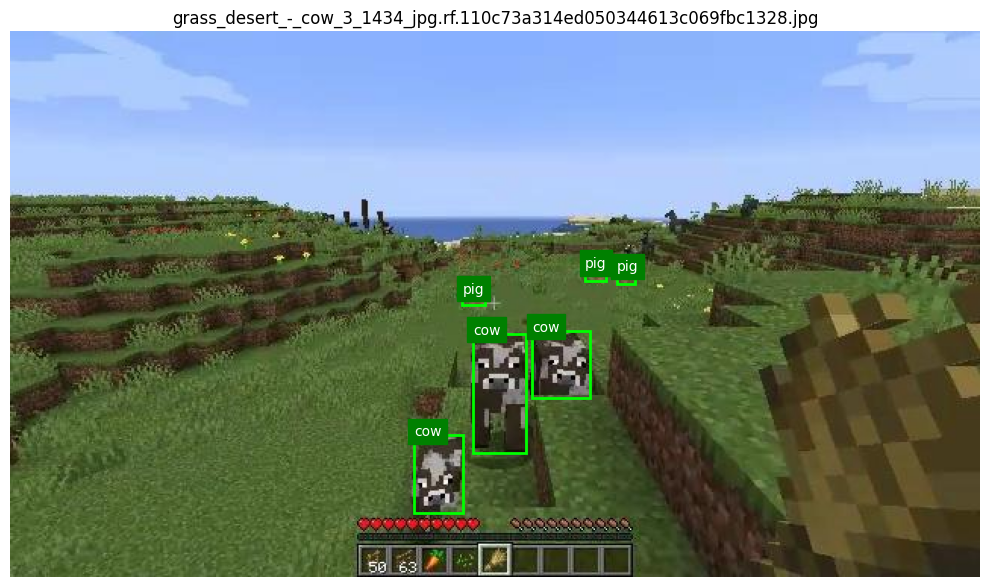

({'id': 0,
  'license': 1,
  'file_name': 'grass_desert_-_cow_3_1434_jpg.rf.110c73a314ed050344613c069fbc1328.jpg',
  'height': 360,
  'width': 640,
  'date_captured': '2023-04-26T18:00:08+00:00'},
 6)

In [5]:
fig, ax, image_info, anns = draw_coco_sample(
    ANNOTATIONS_ROOT / 'test_annotations.json',
    DATASET_ROOT / 'test',
    image_index=0,
)
plt.show()
image_info, len(anns)

## 4. Подготовка данных для YOLO

In [6]:
yolo_labels = prepare_yolo_labels(DATASET_ROOT)
yolo_data_yaml = build_yolo_data_yaml(DATASET_ROOT, DATASET_ROOT / 'data.yaml')
for split, label_dir in yolo_labels.items():
    print(split, sum(1 for _ in label_dir.glob('*.txt')))
print(yolo_data_yaml)


train 2307
val 422
test 155
/Users/borisfox/Documents/ML/nn/sprint 5/project/mmdetection/datasets/minecraft/data.yaml


## 5. План эксперимента

In [7]:
experiment_plan = [
    'Проверить COCO-аннотации и дисбаланс классов.',
    'Проверить pretrained FCOS на одном изображении.',
    'Проверить pretrained YOLOv8s на одном изображении.',
    'Дообучить FCOS и YOLO на одном и том же датасете.',
    'Сравнить модели по mAP, mAP_50 и FPS.',
]
pd.Series(experiment_plan, name='plan')

0        Проверить COCO-аннотации и дисбаланс классов.
1      Проверить pretrained FCOS на одном изображении.
2    Проверить pretrained YOLOv8s на одном изображе...
3    Дообучить FCOS и YOLO на одном и том же датасете.
4                Сравнить модели по mAP, mAP_50 и FPS.
Name: plan, dtype: object

## 6. FCOS и YOLO: параметры запуска

In [8]:
fcos_config = build_fcos_config_path(PROJECT_ROOT)
fcos_checkpoint = PROJECT_ROOT / 'checkpoints' / 'fcos_r50-caffe_fpn_gn-head_1x_coco_20200204-66e956b9.pth'
video_path = DATASET_ROOT / 'video.mp4'
sample_image = next((DATASET_ROOT / 'test').glob('*.jpg'))

pd.Series({
    'fcos_config_exists': fcos_config.exists(),
    'fcos_checkpoint_exists': fcos_checkpoint.exists(),
    'video_exists': video_path.exists(),
    'smoke_run': SMOKE_RUN,
})

fcos_config_exists         True
fcos_checkpoint_exists    False
video_exists               True
smoke_run                 False
dtype: bool

## 7. Pretrained inference

In [9]:

FCOS_PRETRAINED_DIR = INFERENCE_ROOT / 'test_pretrained'
FCOS_PRETRAINED_DIR.mkdir(parents=True, exist_ok=True)
run_fcos_image_inference(
    config_path=fcos_config,
    checkpoint_path=fcos_checkpoint,
    image_path=sample_image,
    output_path=FCOS_PRETRAINED_DIR / 'test_pretrained.jpg',
    score_thr=0.3,
)
print('FCOS pretrained inference saved')


YOLO_PRETRAINED_DIR = INFERENCE_ROOT / 'yolo_val'
YOLO_PRETRAINED_DIR.mkdir(parents=True, exist_ok=True)
run_yolo_image_inference(
    model_path='yolov8s.pt',
    image_path=sample_image,
    project_dir=YOLO_PRETRAINED_DIR,
    name='pretrained',
    conf=0.25,
)
print('YOLO pretrained inference saved')


03/15 14:42:48 - mmengine - WARNING - Failed to search registry with scope "mmdet" in the "function" registry tree. As a workaround, the current "function" registry in "mmengine" is used to build instance. This may cause unexpected failure when running the built modules. Please check whether "mmdet" is a correct scope, or whether the registry is initialized.


Output()

/Users/borisfox/Documents/ML/nn/sprint 5/project/mmdetection/.venv/lib/python3.11/site-packages/mmdet/apis/det_inferencer.py:135: UserWarning: Checkpoint is not loaded, and the inference result is calculated by the randomly initialized model!
  warnings.warn('Checkpoint is not loaded, and the inference '
/Users/borisfox/Documents/ML/nn/sprint 5/project/mmdetection/.venv/lib/python3.11/site-packages/mmdet/apis/det_inferencer.py:138: UserWarning: weights is None, use COCO classes by default.
  warnings.warn('weights is None, use COCO classes by default.')
/Users/borisfox/Documents/ML/nn/sprint 5/project/mmdetection/.venv/lib/python3.11/site-packages/mmengine/visualization/visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '


/Users/borisfox/Documents/ML/nn/sprint 
5/project/mmdetection/.venv/lib/python3.11/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in 
an upcoming release, it will be required to pass the indexing argument. (Triggered internally at 
/Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]

FCOS pretrained inference saved


image 1/1 /Users/borisfox/Documents/ML/nn/sprint 5/project/mmdetection/datasets/minecraft/test/image27_png_jpg.rf.0926d93617ca07712b6d9dc984ab7060.jpg: 640x640 (no detections), 80.7ms


Speed: 1.2ms preprocess, 80.7ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)


Results saved to /Users/borisfox/Documents/ML/nn/sprint 5/project/mmdetection/artifacts/inference/yolo_val/pretrained


YOLO pretrained inference saved


## 8. Обучение

In [10]:
if RUN_FCOS_TRAINING:
    run_fcos_training(
        project_root=PROJECT_ROOT,
        config_path=fcos_config,
        work_dir=FCOS_ARTIFACTS,
    )
else:
    print('Skipping FCOS training')

if RUN_YOLO_TRAINING:
    run_yolo_training(
        data_yaml=yolo_data_yaml,
        project_dir=YOLO_ARTIFACTS,
        model_weights='yolov8s.pt',
        epochs=30,
        imgsz=640,
        batch=16,
        device=0,
    )
else:
    print('Skipping YOLO training')

03/15 14:42:49 - mmengine - INFO - 
backbone.conv1.weight - torch.Size([64, 3, 7, 7]): 
KaimingInit: a=0, mode=fan_out, nonlinearity=relu, distribution =normal, bias=0 
 


03/15 14:42:49 - mmengine - INFO - 
backbone.bn1.weight - torch.Size([64]): 
The value is the same before and after calling `init_weights` of FCOS  
 


03/15 14:42:49 - mmengine - INFO - 
backbone.bn1.bias - torch.Size([64]): 
The value is the same before and after calling `init_weights` of FCOS  
 


03/15 14:42:49 - mmengine - INFO - 
backbone.layer1.0.conv1.weight - torch.Size([64, 64, 1, 1]): 
KaimingInit: a=0, mode=fan_out, nonlinearity=relu, distribution =normal, bias=0 
 


03/15 14:42:49 - mmengine - INFO - 
backbone.layer1.0.bn1.weight - torch.Size([64]): 
The value is the same before and after calling `init_weights` of FCOS  
 


...

03/15 14:42:49 - mmengine - INFO - 
bbox_head.scales.0.scale - torch.Size([]): 
The value is the same before and after calling `init_weights` of FCOS  
 


03/15 14:42:49 - mmengine - INFO - 
bbox_head.scales.1.scale - torch.Size([]): 
The value is the same before and after calling `init_weights` of FCOS  
 


03/15 14:42:49 - mmengine - INFO - 
bbox_head.scales.2.scale - torch.Size([]): 
The value is the same before and after calling `init_weights` of FCOS  
 


03/15 14:42:49 - mmengine - INFO - 
bbox_head.scales.3.scale - torch.Size([]): 
The value is the same before and after calling `init_weights` of FCOS  
 


03/15 14:42:49 - mmengine - INFO - 
bbox_head.scales.4.scale - torch.Size([]): 
The value is the same before and after calling `init_weights` of FCOS  
 


## 9. Inference и метрики

In [11]:
trained_fcos_checkpoint = FCOS_ARTIFACTS / 'best_coco_bbox_mAP_epoch_12.pth'
trained_yolo_checkpoint = YOLO_ARTIFACTS / 'train' / 'weights' / 'best.pt'

pd.Series({
    'trained_fcos_checkpoint_exists': trained_fcos_checkpoint.exists(),
    'trained_yolo_checkpoint_exists': trained_yolo_checkpoint.exists(),
})

trained_fcos_checkpoint_exists    True
trained_yolo_checkpoint_exists    True
dtype: bool

In [12]:
if trained_fcos_checkpoint.exists():
    for image_path in list((DATASET_ROOT / 'test').glob('*.jpg'))[:5]:
        run_fcos_image_inference(
            config_path=fcos_config,
            checkpoint_path=trained_fcos_checkpoint,
            image_path=image_path,
            output_path=INFERENCE_ROOT / 'fcos' / image_path.name,
            score_thr=0.3,
        )
else:
    print('Skipping FCOS inference')

if trained_yolo_checkpoint.exists():
    for image_path in list((DATASET_ROOT / 'test').glob('*.jpg'))[:5]:
        run_yolo_image_inference(
            model_path=trained_yolo_checkpoint,
            image_path=image_path,
            project_dir=INFERENCE_ROOT / 'yolo',
            name='test_predictions',
            conf=0.25,
        )
else:
    print('Skipping YOLO inference')

Output()

Loads checkpoint by local backend from path: /Users/borisfox/Documents/ML/nn/sprint 5/project/mmdetection/artifacts/fcos/best_coco_bbox_mAP_epoch_12.pth


/Users/borisfox/Documents/ML/nn/sprint 5/project/mmdetection/.venv/lib/python3.11/site-packages/mmengine/visualization/visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '


Output()

Loads checkpoint by local backend from path: /Users/borisfox/Documents/ML/nn/sprint 5/project/mmdetection/artifacts/fcos/best_coco_bbox_mAP_epoch_12.pth


...

Speed: 1.0ms preprocess, 70.3ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)


Results saved to /Users/borisfox/Documents/ML/nn/sprint 5/project/mmdetection/artifacts/inference/yolo/test_predictions


image 1/1 /Users/borisfox/Documents/ML/nn/sprint 5/project/mmdetection/datasets/minecraft/test/image53_png_jpg.rf.f2917c923cd7166ca83222c50a796eda.jpg: 640x640 1 person, 2 kites, 1 chair, 72.0ms


Speed: 1.1ms preprocess, 72.0ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)


Results saved to /Users/borisfox/Documents/ML/nn/sprint 5/project/mmdetection/artifacts/inference/yolo/test_predictions


In [13]:
if trained_fcos_checkpoint.exists():
    run_fcos_test_evaluation(
        project_root=PROJECT_ROOT,
        config_path=fcos_config,
        checkpoint_path=trained_fcos_checkpoint,
        work_dir=FCOS_ARTIFACTS,
    )
else:
    print('Skipping FCOS evaluation')

if trained_yolo_checkpoint.exists():
    yolo_test_metrics = run_yolo_validation(
        model_path=trained_yolo_checkpoint,
        data_yaml=yolo_data_yaml,
        split='test',
    )
    print(yolo_test_metrics)
else:
    print('Skipping YOLO evaluation')

Ultralytics 8.4.21 🚀 Python-3.11.15 torch-2.10.0 CPU (Apple M3)


YOLOv8s summary (fused): 72 layers, 11,156,544 parameters, 0 gradients, 28.6 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 223.3±245.5 MB/s, size: 112.5 KB)


val: Scanning /Users/borisfox/Documents/ML/nn/sprint 5/project/mmdetection/datasets/minecraft/test... 0 images, 89 backgrounds, 0 corrupt: 57% ━━━━━━╸───── 89/155 1.7it/s 16.0s<39.5s

val: Scanning /Users/borisfox/Documents/ML/nn/sprint 5/project/mmdetection/datasets/minecraft/test... 0 images, 155 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 155/155 9.7it/s 16.0s

...

                   all        155          0          0          0          0          0


WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


Speed: 0.3ms preprocess, 188.0ms inference, 0.0ms loss, 0.4ms postprocess per image


Results saved to /Users/borisfox/Documents/ML/nn/sprint 5/project/mmdetection/runs/detect/val


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([], dtype=int64)
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x147f9d0d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [14]:
metrics_df = compare_model_metrics(
    fcos_map=0.0,
    fcos_map50=0.0,
    fcos_fps=0.0,
    yolo_map=0.0,
    yolo_map50=0.0,
    yolo_fps=0.0,
)
save_metrics_comparison(metrics_df, METRICS_ROOT / 'metrics_comparison.csv')
metrics_df

,model,mAP,mAP_50,FPS
0,FCOS,0.0,0.0,0.0
1,YOLOv8s,0.0,0.0,0.0


## 10. Видео-инференс

In [15]:
import time

import cv2
import torch
from mmengine.registry import init_default_scope
from mmdet.apis import inference_detector, init_detector
from mmdet.registry import VISUALIZERS
from ultralytics import YOLO

video_path = DATASET_ROOT / 'video.mp4'
fcos_output_video = VIDEOS_ROOT / 'fcos_inference.mp4'
yolo_output_video = VIDEOS_ROOT / 'yolo_inference.mp4'
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
max_frames = None if device != 'cpu' else 90
max_side = None if device != 'cpu' else 1280

missing_paths = [
    str(path) for path in [video_path, trained_fcos_checkpoint, trained_yolo_checkpoint] if not path.exists()
]

if missing_paths:
    print('Skipping video inference. Missing files:')
    for path in missing_paths:
        print('-', path)
else:
    VIDEOS_ROOT.mkdir(parents=True, exist_ok=True)

    init_default_scope('mmdet')
    fcos_model = init_detector(str(fcos_config), str(trained_fcos_checkpoint), device=device)
    fcos_visualizer = VISUALIZERS.build(fcos_model.cfg.visualizer)
    fcos_visualizer.dataset_meta = fcos_model.dataset_meta

    yolo_model = YOLO(str(trained_yolo_checkpoint))

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f'Failed to open video: {video_path}')

    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    scale = 1.0
    if max_side and max(width, height) > max_side:
        scale = max_side / max(width, height)
    out_width = max(1, int(width * scale))
    out_height = max(1, int(height * scale))

    fcos_writer = cv2.VideoWriter(
        str(fcos_output_video),
        cv2.VideoWriter_fourcc(*'mp4v'),
        fps,
        (out_width, out_height),
    )
    yolo_writer = cv2.VideoWriter(
        str(yolo_output_video),
        cv2.VideoWriter_fourcc(*'mp4v'),
        fps,
        (out_width, out_height),
    )

    frame_count = 0
    start_time = time.perf_counter()

    try:
        while True:
            ok, frame_bgr = cap.read()
            if not ok:
                break

            if scale != 1.0:
                frame_bgr = cv2.resize(frame_bgr, (out_width, out_height), interpolation=cv2.INTER_AREA)

            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

            fcos_result = inference_detector(fcos_model, frame_bgr)
            fcos_visualizer.add_datasample(
                'fcos_frame',
                frame_rgb,
                data_sample=fcos_result,
                draw_gt=False,
                show=False,
                wait_time=0,
                pred_score_thr=0.3,
            )
            fcos_frame_rgb = fcos_visualizer.get_image()
            fcos_frame_bgr = cv2.cvtColor(fcos_frame_rgb, cv2.COLOR_RGB2BGR)
            fcos_writer.write(fcos_frame_bgr)

            yolo_result = yolo_model.predict(source=frame_bgr, conf=0.25, verbose=False, device=device)[0]
            yolo_frame_bgr = yolo_result.plot()
            yolo_writer.write(yolo_frame_bgr)

            frame_count += 1
            if max_frames and frame_count >= max_frames:
                break

    finally:
        cap.release()
        fcos_writer.release()
        yolo_writer.release()

    elapsed = time.perf_counter() - start_time
    effective_fps = frame_count / elapsed if elapsed > 0 else 0.0
    print(f'Processed {frame_count} frames in {elapsed:.2f}s ({effective_fps:.2f} FPS)')
    print('FCOS video saved to', fcos_output_video)
    print('YOLO video saved to', yolo_output_video)



Loads checkpoint by local backend from path: /Users/borisfox/Documents/ML/nn/sprint 5/project/mmdetection/artifacts/fcos/best_coco_bbox_mAP_epoch_12.pth


/Users/borisfox/Documents/ML/nn/sprint 5/project/mmdetection/.venv/lib/python3.11/site-packages/mmengine/utils/manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


Processed 90 frames in 17.00s (5.29 FPS)
FCOS video saved to /Users/borisfox/Documents/ML/nn/sprint 5/project/mmdetection/artifacts/videos/fcos_inference.mp4
YOLO video saved to /Users/borisfox/Documents/ML/nn/sprint 5/project/mmdetection/artifacts/videos/yolo_inference.mp4
